In [ ]:
# Initialize the environment and load the data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset: If running on a local machine, ensure the path is correct for your environment
df = pd.read_csv("/Users/work/Documents/GitHub/Miller-Data-Science-Portfolio/TidyData-Project/Data/olympics_08_medalists.csv")
# Preview the first few rows of the dataset
df.head()

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [65]:
# Melt the DataFrame from Wide to Long Format
df_melted = df.melt(
    id_vars=["medalist_name"],
    var_name="event",
    value_name="medal"
)

df_melted.head()

,medalist_name,event,medal
0,Aaron Armstrong,male_archery,NaN
1,Aaron Peirsol,male_archery,NaN
2,Abdullo Tangriev,male_archery,NaN
3,Abeer Abdelrahman,male_archery,NaN
4,Abhinav,male_archery,NaN


In [66]:
# Drop rows with missing medal values post melt function
df_melted = df_melted.dropna()
df_melted.head()


,medalist_name,event,medal
177,Bair Badënov,male_archery,bronze
676,Ilario Di Buò,male_archery,silver
682,Im Dong-hyun,male_archery,gold
760,Jiang Lin,male_archery,bronze
920,Lee Chang-hwan,male_archery,gold


In [67]:
# Split the "event" column into 2 separate columns for gender and sport and drop the original "event" column
df_melted[["gender", "sport"]] = df_melted["event"].str.split("_", n=1, expand=True)
df_melted = df_melted.drop(columns=["event"])

#Capitalize the values in the newly created columns
df_melted["gender"] = df_melted["gender"].str.capitalize()
df_melted["sport"] = df_melted["sport"].str.title()
df_melted["medal"] = df_melted["medal"].str.capitalize()
# Replace "Athletics" with "Track & Field" in the "sport" column for better clarity
df_melted["sport"] = df_melted["sport"].replace("Athletics", "Track & Field")
df_melted

,medalist_name,medal,gender,sport
177,Bair Badënov,Bronze,Male,Archery
676,Ilario Di Buò,Silver,Male,Archery
682,Im Dong-hyun,Gold,Male,Archery
760,Jiang Lin,Bronze,Male,Archery
920,Lee Chang-hwan,Gold,Male,Archery
...,...,...,...,...
130932,Steeve Guénot,Gold,Male,Greco-Roman Wrestling
131159,Yannick Szczepaniak,Bronze,Male,Greco-Roman Wrestling
131162,Yavor Yanakiev,Bronze,Male,Greco-Roman Wrestling
131200,Yury Patrikeyev,Bronze,Male,Greco-Roman Wrestling


In [ ]:
# Aggregate the data to count the number of medals by sport and gender
medal_counts = df_melted.groupby(["sport", "gender"]).size().reset_index(name="count")

# Create a pivot table to reshape the data for better visualization
pivot = medal_counts.pivot(index='sport', columns='gender', values='count').fillna(0)
pivot

gender,Female,Male
sport,,
Archery,9.0,11.0
Artistic Gymnastics,20.0,29.0
Association Football,54.0,55.0
Badminton,10.0,12.0
Baseball,0.0,72.0
Basketball,36.0,35.0
Beach Volleyball,6.0,6.0
Bmx,3.0,3.0
Boxing,0.0,44.0


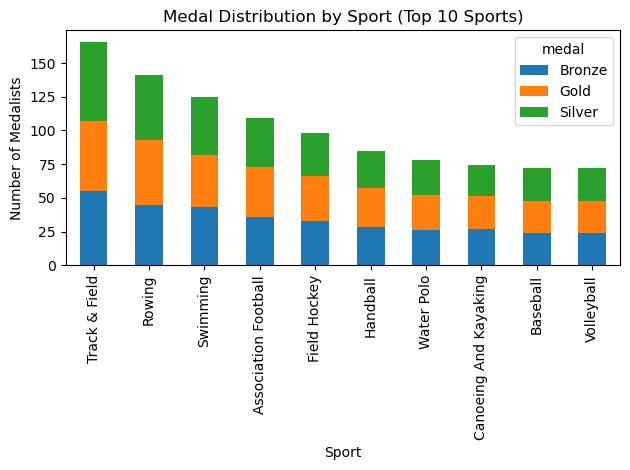

In [ ]:
# Create a bar plot to visualize the distribution of medals among the sports with the highest medal counts
plot = df_melted.groupby(["sport", "medal"]).size().unstack()

plot.loc[plot.sum(axis=1).sort_values(ascending=False).head(10).index] \
    .plot(kind="bar", stacked=True)

plt.title("Medal Distribution by Sport (Top 10 Sports)")
plt.xlabel("Sport")
plt.ylabel("Number of Medalists")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

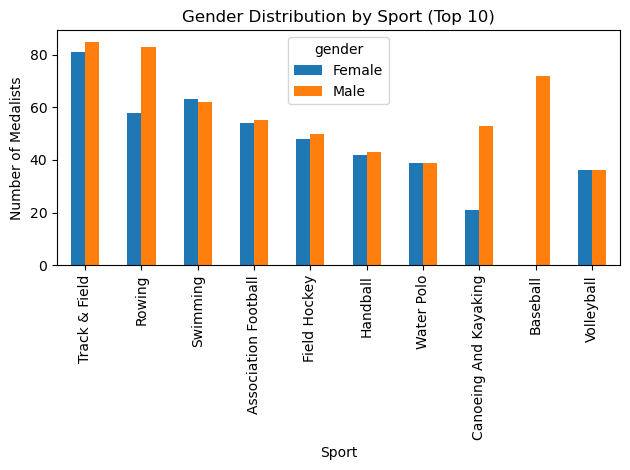

In [ ]:
# Create a second bar plot to visualize the distribution of medals among the sports with the highest medal counts, but this time sperating medal counts by gender in order to see the gender distribution by sport
plot2 = df_melted.groupby(["sport", "gender"]).size().unstack()

plot2.loc[plot2.sum(axis=1).sort_values(ascending=False).head(10).index] \
    .plot(kind="bar")

plt.title("Gender Distribution by Sport (Top 10)")
plt.xlabel("Sport")
plt.ylabel("Number of Medalists")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()